# JOUR 2 — Apprentissage supervisé : split, preprocessing, modèles et évaluation

## Reprise exacte du travail du Jour 1
Nous importons **`AI4I_J1_PREPARED.csv`**, c'est-à-dire la base exportée à la fin du notebook précédent. Elle est déjà nettoyée des erreurs factuelles, mais conserve volontairement les valeurs manquantes qui nécessitent une décision statistique.

### Objectifs du Jour 2
Nous allons suivre le workflow :

**problème → X/y → TRAIN/VALIDATION/TEST → preprocessing appris sur TRAIN → modèles → métriques → comparaison → choix → TEST final.**

Nous traiterons deux problèmes supervisés :
1. **Classification** : prédire `Machine failure` (panne oui/non).
2. **Régression** : prédire pédagogiquement `Torque [Nm]`, une variable continue, afin d'appliquer les modèles de régression du support.

### Règle du jour
> **TRAIN apprend. VALIDATION aide à choisir. TEST mesure à la fin.**

TEST ne doit jamais servir à calculer une médiane, un scaler, choisir un modèle ou régler un hyperparamètre.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

path = Path("AI4I_J1_PREPARED.csv")
if not path.exists():
    path = Path("/mnt/data/AI4I_J1_PREPARED.csv")

df = pd.read_csv(path)
print("Dimensions :", df.shape)
print("NaN restants après le nettoyage factuel J1 :", int(df.isna().sum().sum()))
display(df.head())

Dimensions : (10000, 14)
NaN restants après le nettoyage factuel J1 : 434


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551.0,42.8,0.0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408.0,46.3,3.0,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498.0,49.4,5.0,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433.0,39.5,7.0,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408.0,40.0,9.0,0,0,0,0,0,0


### Vérification de continuité
Nous retrouvons bien **10 000 lignes, 14 colonnes et 434 NaN**. C'est exactement l'état dans lequel le Jour 1 a exporté la base.

Les NaN ne signifient donc pas que le nettoyage a échoué : ils représentent les opérations statistiques que nous avions volontairement reportées.

# PARTIE A — CLASSIFICATION SUPERVISÉE

Objectif : prédire **`Machine failure`**.

Nous excluons :
- les identifiants `UDI`, `Product ID`;
- les indicateurs `TWF/HDF/PWF/OSF/RNF`, car ils révèlent directement des informations sur le type de panne et créeraient une fuite pour cette cible.

In [2]:
target = "Machine failure"
excluded = ["UDI","Product ID","Machine failure","TWF","HDF","PWF","OSF","RNF"]

X = df.drop(columns=excluded)
y = df[target].astype(int)

print("X :", list(X.columns))
print("\nDistribution cible :")
display(y.value_counts().to_frame("effectif"))
display(y.value_counts(normalize=True).round(4).to_frame("proportion"))

X : ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

Distribution cible :


,effectif
Machine failure,
0,9661
1,339


,proportion
Machine failure,
0,0.9661
1,0.0339


### Interprétation de la cible
Après exclusion des identifiants et des colonnes de fuite, X contient **6 variables utiles**.

La cible est fortement déséquilibrée :
- **9 661 observations sans panne (96,61 %)**
- **339 pannes (3,39 %)**

Conséquence : un modèle qui prédit toujours « pas de panne » aurait déjà environ 96,6 % d'accuracy. **L'accuracy seule sera donc insuffisante.**

## 1. TRAIN / VALIDATION / TEST

Le support distingue trois rôles :
- **TRAIN** : apprendre preprocessing + modèle ;
- **VALIDATION** : comparer modèles/hyperparamètres ;
- **TEST** : évaluation finale.

On fait ici environ 70/15/15 et on stratifie pour conserver la proportion de pannes.

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

for nom, xx, yy in [("TRAIN",X_train,y_train),("VALID",X_val,y_val),("TEST",X_test,y_test)]:
    print(nom, xx.shape, "| taux panne =", round(yy.mean(),4))

TRAIN (7000, 6) | taux panne = 0.0339
VALID (1500, 6) | taux panne = 0.034
TEST (1500, 6) | taux panne = 0.034


### Pourquoi trois ensembles ?
Nous obtenons **7 000 observations TRAIN, 1 500 VALIDATION et 1 500 TEST**. La stratification conserve environ **3,4 % de pannes** dans chaque ensemble.

- TRAIN : apprendre les paramètres et le modèle.
- VALIDATION : comparer les modèles.
- TEST : évaluation finale, après le choix.

Cette séparation évite d'optimiser indirectement le modèle sur son examen final.

## 2. Nettoyage statistique APRÈS le split

Maintenant seulement :
- médiane numérique : **fit sur TRAIN** ;
- modalité la plus fréquente : **fit sur TRAIN** ;
- StandardScaler : **fit sur TRAIN** ;
- OneHotEncoder : catégories apprises sur TRAIN.

TEST n'apprend rien. Il reçoit uniquement les paramètres déjà appris.

Le `Pipeline` et le `ColumnTransformer` automatisent cette règle et évitent le data leakage.

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])

print("Numériques :", num_cols)
print("Catégorielles :", cat_cols)

Numériques : ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
Catégorielles : ['Type']


### Pourquoi un `Pipeline` ?
Nous avons 5 variables numériques et 1 catégorielle.

Pour les numériques : **imputation médiane → standardisation**.  
Pour `Type` : **imputation de la modalité fréquente → One-Hot Encoding**.

Le pipeline est essentiel : lors de `fit(X_train, y_train)`, les paramètres sont appris uniquement sur TRAIN ; lors de `predict(X_test)`, ces mêmes paramètres sont simplement appliqués à TEST.

## 3. Démonstration : où la médiane est-elle apprise ?

On ajuste une copie du preprocessing sur TRAIN, puis on inspecte les médianes apprises. TEST n'intervient jamais dans ce calcul.

In [5]:
prep_demo = preprocessor.fit(X_train, y_train)
medianes_train = prep_demo.named_transformers_["num"].named_steps["imputer"].statistics_
display(pd.DataFrame({"variable":num_cols, "médiane_apprise_sur_TRAIN":medianes_train}))

,variable,médiane_apprise_sur_TRAIN
0,Air temperature [K],300.1
1,Process temperature [K],310.1
2,Rotational speed [rpm],1504.0
3,Torque [Nm],40.1
4,Tool wear [min],107.0


### Preuve concrète : les médianes viennent de TRAIN
Les médianes apprises sont notamment **300,1 K**, **310,1 K**, **1504 rpm**, **40,1 Nm** et **107 min**.

On ne recalcule pas une nouvelle médiane sur VALIDATION ou TEST. Une observation manquante de TEST sera remplacée avec la médiane **apprise sur TRAIN**.

## 4. Erreur à éviter

**Incorrect :**
```python
imputer.fit(X)       # X contient aussi validation/test
scaler.fit(X)
```

**Correct :**
```python
pipeline.fit(X_train, y_train)
pipeline.predict(X_val)
pipeline.predict(X_test)
```

Le modèle et le preprocessing n'apprennent jamais sur TEST.

# ARRÊT — Classification : LR, k-NN, arbre, SVM

On construit plusieurs modèles avec **le même preprocessing** et le même split.

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)

models = {
    "LogisticRegression": LogisticRegression(max_iter=3000, class_weight="balanced"),
    "k-NN": KNeighborsClassifier(n_neighbors=7),
    "DecisionTree": DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=42),
    "SVM-RBF": SVC(kernel="rbf", C=1.0, gamma="scale", class_weight="balanced")
}

fitted = {}
rows = []

for name, model in models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_val)
    score = (pipe.predict_proba(X_val)[:,1] if hasattr(model, "predict_proba")
             else pipe.decision_function(X_val))
    fitted[name] = pipe
    rows.append({
        "modèle":name,
        "accuracy":accuracy_score(y_val,pred),
        "precision":precision_score(y_val,pred,zero_division=0),
        "recall":recall_score(y_val,pred,zero_division=0),
        "F1":f1_score(y_val,pred,zero_division=0),
        "ROC-AUC":roc_auc_score(y_val,score)
    })

comparison_clf = pd.DataFrame(rows).sort_values("F1",ascending=False)
display(comparison_clf.round(3))

,modèle,accuracy,precision,recall,F1,ROC-AUC
2,DecisionTree,0.943,0.351,0.784,0.485,0.798
3,SVM-RBF,0.922,0.288,0.882,0.435,0.960
1,k-NN,0.969,0.692,0.176,0.281,0.839
0,LogisticRegression,0.831,0.134,0.725,0.226,0.866


### Comparaison des classifieurs — que disent les résultats ?
Les modèles n'ont pas le même comportement.

- **Decision Tree** obtient ici le meilleur **F1 ≈ 0,485** sur VALIDATION.
- **SVM** possède un excellent **ROC-AUC ≈ 0,960** et un recall élevé, mais davantage de fausses alertes.
- **k-NN** affiche une accuracy élevée mais un **recall faible ≈ 0,176** : il rate beaucoup de pannes.
- **Logistic Regression** détecte davantage de pannes que k-NN, mais avec une précision faible.

C'est exactement pourquoi on ne choisit pas un modèle uniquement avec l'accuracy.

## 5. Lire les métriques

La classe panne est rare : l'accuracy seule peut être trompeuse.

- **Precision** : parmi les alertes, combien sont réellement des pannes ?
- **Recall** : parmi les vraies pannes, combien détectons-nous ?
- **F1** : compromis precision/recall.
- **ROC-AUC** : qualité de classement sur différents seuils.

Le choix du “meilleur” modèle dépend donc du coût métier des faux positifs et faux négatifs.

## 6. Matrice de confusion du modèle choisi sur VALIDATION

On prend ici automatiquement le meilleur F1 de validation pour illustrer. Le TEST reste fermé jusqu'à la décision finale.

Modèle retenu sur validation : DecisionTree


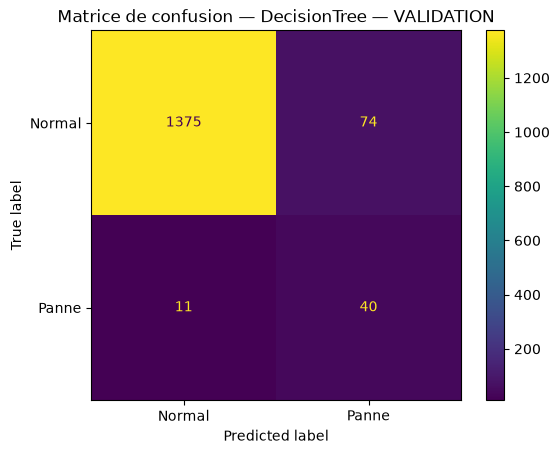

In [7]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

best_name = comparison_clf.iloc[0]["modèle"]
best_clf = fitted[best_name]
pred_val = best_clf.predict(X_val)

print("Modèle retenu sur validation :", best_name)
ConfusionMatrixDisplay.from_predictions(y_val, pred_val, display_labels=["Normal","Panne"])
plt.title(f"Matrice de confusion — {best_name} — VALIDATION")
plt.show()

### Matrice de confusion : comment la lire ?
La matrice oppose **réalité** et **prédiction**. Elle permet de compter :
- vrais négatifs : machines normales correctement reconnues ;
- faux positifs : fausses alertes ;
- faux négatifs : pannes ratées ;
- vrais positifs : pannes correctement détectées.

Dans une maintenance prédictive, le **faux négatif** peut être particulièrement coûteux : une panne réelle n'a pas été signalée.

## 7. Évaluation finale sur TEST

Une fois le modèle choisi, on regarde TEST **une seule fois** pour estimer la généralisation finale.

In [8]:
pred_test = best_clf.predict(X_test)
model_obj = best_clf.named_steps["model"]
score_test = (best_clf.predict_proba(X_test)[:,1] if hasattr(model_obj,"predict_proba")
              else best_clf.decision_function(X_test))

print("Accuracy :", round(accuracy_score(y_test,pred_test),3))
print("Precision:", round(precision_score(y_test,pred_test,zero_division=0),3))
print("Recall   :", round(recall_score(y_test,pred_test,zero_division=0),3))
print("F1       :", round(f1_score(y_test,pred_test,zero_division=0),3))
print("ROC-AUC  :", round(roc_auc_score(y_test,score_test),3))
print("\nConfusion :\n", confusion_matrix(y_test,pred_test))

Accuracy : 0.943
Precision: 0.356
Recall   : 0.824
F1       : 0.497
ROC-AUC  : 0.86

Confusion :
 [[1373   76]
 [   9   42]]


### TEST final du classifieur retenu
Sur TEST, l'arbre obtient environ **Accuracy 0,943 ; Precision 0,356 ; Recall 0,824 ; F1 0,497 ; ROC-AUC 0,86**.

La matrice de confusion est :
`[[1373, 76], [9, 42]]`.

Lecture concrète : **42 pannes sont détectées et 9 sont ratées**, tandis que 76 machines normales déclenchent une fausse alerte. Le recall élevé est intéressant si le métier préfère déclencher quelques contrôles supplémentaires plutôt que manquer une panne.

# PARTIE B — RÉGRESSION

Pour pratiquer les modèles de régression du Jour 2 sur le même dataset, nous choisissons **`Torque [Nm]` comme cible pédagogique continue**.

C'est un exercice de méthode : il ne faut pas confondre cela avec le cas métier principal de prédiction de panne.

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures

reg_target = "Torque [Nm]"
reg_features = ["Air temperature [K]", "Process temperature [K]",
                "Rotational speed [rpm]", "Tool wear [min]"]

Xr = df[reg_features].copy()
yr = df[reg_target].copy()

# La cible ne doit pas être imputée : on retire seulement les lignes où y manque.
mask = yr.notna()
Xr, yr = Xr.loc[mask], yr.loc[mask]

Xr_train, Xr_temp, yr_train, yr_temp = train_test_split(
    Xr, yr, test_size=.30, random_state=42
)
Xr_val, Xr_test, yr_val, yr_test = train_test_split(
    Xr_temp, yr_temp, test_size=.50, random_state=42
)

print(Xr_train.shape, Xr_val.shape, Xr_test.shape)

(6945, 4) (1488, 4) (1489, 4)


### Passage à la régression
Pour la régression, la cible `Torque [Nm]` doit être connue : les lignes où **y est manquant sont retirées**. On ne doit pas imputer artificiellement la cible.

Les variables X peuvent en revanche contenir des valeurs manquantes : leur imputation reste dans le pipeline et sera apprise sur TRAIN.

## 8. Preprocessing régression

Même principe : l'imputation et le scaling sont dans le pipeline, donc ils sont appris sur TRAIN.

In [10]:
reg_prep = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

reg_models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1, max_iter=20000)
}

reg_fitted, reg_rows = {}, []

for name, model in reg_models.items():
    pipe = Pipeline([("prep",reg_prep),("model",model)])
    pipe.fit(Xr_train,yr_train)
    pred = pipe.predict(Xr_val)
    reg_fitted[name]=pipe
    reg_rows.append({
        "modèle":name,
        "MAE":mean_absolute_error(yr_val,pred),
        "RMSE":mean_squared_error(yr_val,pred)**0.5,
        "R²":r2_score(yr_val,pred)
    })

comparison_reg = pd.DataFrame(reg_rows).sort_values("RMSE")
display(comparison_reg.round(3))

,modèle,MAE,RMSE,R²
2,Lasso,3.663,4.936,0.758
1,Ridge,3.658,4.941,0.757
0,LinearRegression,3.658,4.941,0.757


### Résultats des modèles linéaires
`LinearRegression`, `Ridge` et `Lasso` donnent ici des performances proches, autour de **R² ≈ 0,76** et **RMSE ≈ 4,94 Nm** sur VALIDATION.

Interprétation :
- le modèle explique environ 76 % de la variabilité de la cible ;
- l'erreur quadratique moyenne ramenée à l'unité de la cible est d'environ 4,9 Nm ;
- la régularisation n'apporte pas ici un gain spectaculaire dans cette configuration.

## 9. Régression polynomiale

`PolynomialFeatures(degree=2)` ajoute carrés et interactions. Cela permet une relation plus flexible, mais augmente aussi le risque de surapprentissage.

On l'évalue sur la même VALIDATION.

In [11]:
poly_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])
poly_model.fit(Xr_train,yr_train)
pred_poly = poly_model.predict(Xr_val)

poly_row = {
    "modèle":"Polynomial(deg2)+Ridge",
    "MAE":mean_absolute_error(yr_val,pred_poly),
    "RMSE":mean_squared_error(yr_val,pred_poly)**0.5,
    "R²":r2_score(yr_val,pred_poly)
}
comparison_reg = pd.concat([comparison_reg,pd.DataFrame([poly_row])],ignore_index=True)
display(comparison_reg.sort_values("RMSE").round(3))

,modèle,MAE,RMSE,R²
3,Polynomial(deg2)+Ridge,3.061,3.976,0.843
0,Lasso,3.663,4.936,0.758
1,Ridge,3.658,4.941,0.757
2,LinearRegression,3.658,4.941,0.757


### Apport du modèle polynomial
Le modèle **Polynomial(degré 2) + Ridge** améliore nettement la validation : **R² ≈ 0,843** et **RMSE ≈ 3,976**.

Cela suggère que la relation entre les variables physiques et le couple n'est pas parfaitement linéaire. Les termes au carré et interactions captent une partie de cette structure.

Attention : augmenter encore le degré pourrait réduire l'erreur TRAIN tout en dégradant VALIDATION — ce serait du **surapprentissage**.

## 10. Choix et TEST final en régression

On choisit sur VALIDATION, puis on évalue sur TEST.

In [12]:
# Reconstruire le meilleur modèle parmi ceux comparés.
best_reg_name = comparison_reg.sort_values("RMSE").iloc[0]["modèle"]
best_reg = poly_model if best_reg_name=="Polynomial(deg2)+Ridge" else reg_fitted[best_reg_name]

pred = best_reg.predict(Xr_test)
print("Modèle retenu :", best_reg_name)
print("MAE :", round(mean_absolute_error(yr_test,pred),3))
print("RMSE:", round(mean_squared_error(yr_test,pred)**0.5,3))
print("R²  :", round(r2_score(yr_test,pred),3))

Modèle retenu : Polynomial(deg2)+Ridge
MAE : 3.065
RMSE: 4.021
R²  : 0.847


### TEST final en régression
Le modèle retenu conserve ses performances sur TEST :
- **MAE ≈ 3,065 Nm**
- **RMSE ≈ 4,021 Nm**
- **R² ≈ 0,847**

La proximité entre VALIDATION et TEST est rassurante : le choix du modèle ne semble pas dépendre d'un résultat exceptionnel sur un seul échantillon.

# SYNTHÈSE — workflow complet

### Jour 1 — avant split
1. Charger / visualiser.
2. Comprendre structure et types.
3. Détecter valeurs manquantes.
4. Supprimer doublons exacts.
5. Corriger incohérences factuelles.
6. Marquer valeurs impossibles.
7. Identifier IDs / colonnes dangereuses.
8. EDA.
9. Exporter une base préparée — **sans apprendre de médiane/scaler sur toute la donnée**.

### Jour 2 — après split
1. Définir X/y.
2. TRAIN / VALIDATION / TEST.
3. Fit imputation/encodage/scaling sur TRAIN.
4. Transform validation/test avec les mêmes paramètres.
5. Entraîner plusieurs modèles.
6. Comparer sur VALIDATION.
7. Choisir.
8. Évaluer une seule fois sur TEST.

C'est cette chaîne, plus que la mémorisation d'un algorithme isolé, que les étudiants doivent savoir reproduire.